In [46]:
import math
import numpy as np
import pandas as pd
import scipy as sc
import matplotlib.pyplot as plt
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.5/dist-packages/IPython/core/magics/pylab.py:160: UserWarning: pylab import has clobbered these variables: ['rate']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


Некоторые константы

In [47]:
Q_EC_76As=0.9233 #in MeV
Z_76As=33

g_a_g_v=1.297 #ratio of vector and axial coupling constants

Функция для расчета порога реакции

In [48]:
def Q_k_func(E_k, Q_EC):
    #Считаем порог реакции, E_k - энергия возбужденного состояния
    #E_k in KeV
    return Q_EC+E_k/1000

Привиденная энергия вылетающего электрона: $\epsilon_e = \frac{E_{\nu}-Q_k}{m_e} + 1$

In [49]:
def e_e_func(E_nu, E_k, Q_EC):
    #Считаем привиденную энергию вылетающего электрона. Если энергия налетающего нейтрино E_nu
    #меньше порога, возвращаем 0 для обнуления итогового сечения
    #E_nu in MeV
    q=Q_k_func(E_k, Q_EC) #порог реакции
    if E_nu>q: return 1+(E_nu-q)/0.511
    else: return 0 

Привиденный импульс электрона: $\pi_e=\sqrt{\epsilon_e^2 -1}$

In [50]:
def Pi_e_func(e_e):
    #Привиденный импульс электрона, вычисляется через привиденную энергию; ** означает степень  
    if e_e>1: return math.sqrt(e_e**2 - 1)
    else: return 0

IAS для Ge или As?
B(F) = N - Z 
для германия B(F) = 12

In [51]:
BF_Ge = 12
#IAS_Ge = 8.308
IAS_Ge = np.arange(8.100, 8.4, 0.001)

In [52]:
IAS_Ge

array([ 8.1  ,  8.101,  8.102,  8.103,  8.104,  8.105,  8.106,  8.107,
        8.108,  8.109,  8.11 ,  8.111,  8.112,  8.113,  8.114,  8.115,
        8.116,  8.117,  8.118,  8.119,  8.12 ,  8.121,  8.122,  8.123,
        8.124,  8.125,  8.126,  8.127,  8.128,  8.129,  8.13 ,  8.131,
        8.132,  8.133,  8.134,  8.135,  8.136,  8.137,  8.138,  8.139,
        8.14 ,  8.141,  8.142,  8.143,  8.144,  8.145,  8.146,  8.147,
        8.148,  8.149,  8.15 ,  8.151,  8.152,  8.153,  8.154,  8.155,
        8.156,  8.157,  8.158,  8.159,  8.16 ,  8.161,  8.162,  8.163,
        8.164,  8.165,  8.166,  8.167,  8.168,  8.169,  8.17 ,  8.171,
        8.172,  8.173,  8.174,  8.175,  8.176,  8.177,  8.178,  8.179,
        8.18 ,  8.181,  8.182,  8.183,  8.184,  8.185,  8.186,  8.187,
        8.188,  8.189,  8.19 ,  8.191,  8.192,  8.193,  8.194,  8.195,
        8.196,  8.197,  8.198,  8.199,  8.2  ,  8.201,  8.202,  8.203,
        8.204,  8.205,  8.206,  8.207,  8.208,  8.209,  8.21 ,  8.211,
      

### Fermi-function from Numerical Tables for Beta-Decay and Electron Capture

Ферми функия из оцифрованных немецких таблиц. Считываем данные

In [53]:
Fermi_func_new_data = pd.read_excel('../../fermi_func_tables/from_1968/13.xlsx')
Fermi_func_new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 14 columns):
P              49 non-null float64
F0L0           49 non-null float64
L0             48 non-null object
1z             48 non-null float64
13             48 non-null float64
ELECTRON
14    48 non-null float64
Z= 33
Izt      48 non-null float64
A= 77          48 non-null float64
A,             48 non-null float64
A2             48 non-null float64
VI2            48 non-null float64
912            48 non-null float64
12             48 non-null float64
Unnamed: 13    48 non-null float64
dtypes: float64(13), object(1)
memory usage: 5.4+ KB


Функция для расчета интерполированного значения. В таблице дана зависимость от импульса вылетающего электрона. Переводим ее в зав-ть от энергии электрона

In [54]:
e_e3 = np.sqrt( np.square( Fermi_func_new_data['P'].values ) + 1 ) #энергия вылетающего электрона
def num_tables_func(x):
    #x in units of mc^2
    return np.interp(x=x, xp=e_e3, fp=Fermi_func_new_data['F0L0'].values )

### B(GT) data

In [56]:
BGT=pd.read_csv('../B(GT) peaks processing//clear_B(GT).csv') #таблица со значениями B(GT)
BGT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 5 columns):
Unnamed: 0        73 non-null int64
Ex                73 non-null float64
Jpi               73 non-null object
diff cross-sec    73 non-null float64
B(GT)             73 non-null float64
dtypes: float64(3), int64(1), object(1)
memory usage: 2.9+ KB


In [57]:
BGT['B(GT)'] = BGT['B(GT)']/10 #делим на 10 т.к. в таблице все значения домножены на 10

In [58]:
BGT = BGT[ BGT['Jpi'] == '1' ]

In [59]:
BGT

,Unnamed: 0,Ex,Jpi,diff cross-sec,B(GT)
0,1,86.0,1,1.173,0.120
1,2,120.0,1,0.318,0.033
2,3,265.0,1,0.113,0.010
4,31,513.8,1,0.725,0.071
8,9,864.0,1,0.284,0.025
9,10,936.0,1,0.209,0.018
11,12,1063.0,1,1.230,0.136
12,13,1098.0,1,0.157,0.015
13,14,1157.0,1,0.495,0.056
14,15,1235.0,1,0.298,0.028


### BS05_OP flux

Используем потоки солнечных нейтрино из модели BS05(OP)

In [60]:
BS05_OP=pd.read_csv('../Vyborov_results/Fluxes/AllFluxes_BS05(OP).csv', sep=';')
BS05_OP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
energy    2000 non-null float64
pp        2000 non-null float64
hep       2000 non-null float64
N         2000 non-null float64
F         2000 non-null float64
O         2000 non-null float64
B         2000 non-null float64
dtypes: float64(7)
memory usage: 109.5 KB


создаем словарь, где ключ - название канала нейтрино (напр O или F), значение - двумерный массив, характеризующий интеполированные значения энергии и амплитуды для даннаго канала нейтрино 

In [61]:
all_fluxes_step = 0.001
Energy_all_fluxes = np.arange(0,20,0.001) #массив характеризующий шаги интегрирования

In [62]:
BS05_OP_dict = {}
for elem in list(BS05_OP.columns)[1:]:
    BS05_OP_dict.update({ elem : 
                        np.interp(x=Energy_all_fluxes, xp=BS05_OP['energy'], 
                                  fp=BS05_OP[elem] ) })

### Cross-section and total rate

Сечение по Иджири $\sigma_k={(1.597\times10^{-44}\ cm^2)}\epsilon_e \pi_e m_e^2 F(Z,E_e) [B(F)_k + (\frac{g_a}{g_v})^2 B(GT)_k] $ 

In [63]:
def sigma_k_Ejiri_num_tab(E_nu, E_k, BGT_k, Z, Q_EC):
    #сечение k-го возб. состояния по Иджири
    e_e=e_e_func(E_nu, E_k, Q_EC) #энергия вылетающего электрона
    Pi_e=Pi_e_func(e_e) #его импульс
    F_col=num_tables_func(e_e) #значение ферм-функции при такой энергии
    #if E_nu == IAS_Ge:
    #    return e_e*Pi_e*F_col*math.pow(0.511,2)*math.pow(g_a_g_v,2)*(BGT_k+BF_Ge)*1.597*math.pow(10,-44)
    if 8.100 <= E_nu <= 8.400: 
        return e_e*Pi_e*F_col*math.pow(0.511,2)*math.pow(g_a_g_v,2)*(BGT_k+BF_Ge)*1.597*math.pow(10,-44)
    
    else:
        return e_e*Pi_e*F_col*math.pow(0.511,2)*math.pow(g_a_g_v,2)*BGT_k*1.597*math.pow(10,-44)

Считаем полное сечение реакции в два вложеных цикла 

sigma_k_Ejiri_num_tab - сечение к-го возбужденного состояния с параметрами BGT_k, E_k, E_nu, где BGT_k - значение B(GT) для к-го возб. состояния; E_k - энергия к-го возб. состояния; E_nu - энергия налетающего нейтрино. В первом цикле для фиксированной энергии проходимся по всем возб. состояниям, считаем сечение и суммируем его; это цикл for (BGT_k, E_k). Во втором цикле идем по всем энергиям налетающего нейтрино; это цикл for E_nu


In [64]:
#метод Иджири, Ферми функция немцев, все возб. состояния
#Ej_76As_num_tab_all_fluxes - массив со значениями суммарного сечения
Ej_76As_num_tab_all_fluxes=[sum([sigma_k_Ejiri_num_tab(E_nu, E_k, BGT_k, Z_76As, Q_EC_76As) 
                                 for (BGT_k, E_k) in zip(BGT['B(GT)'].values, BGT['Ex'].values)]) 
                            for E_nu in Energy_all_fluxes]



Считаем свертку потока с сечением. 
BS05_OP_dict[elem] - массив со значениями амплитуды потока нейтрино для канала elem.
Ej_76As_num_tab_all_fluxes - массив со значениями суммарного сечения.
all_fluxes_step - шаг интегрирования.
math.pow(10,36) - для получения итогового значения в SNU. Total rate no pep - суммарная свертка по всем каналам без учета канала pep.

In [65]:
sum_rates_no_pep = 0
for elem in list(BS05_OP_dict.keys()):
    rate = sum(BS05_OP_dict[elem]*Ej_76As_num_tab_all_fluxes*all_fluxes_step) * math.pow(10,36)
    print(elem, ' ', rate)
    sum_rates_no_pep += rate
print('Total rate no pep', sum_rates_no_pep)

B   253.519150815
F   0.0210642906202
hep   0.31465071786
O   0.827732601889
pp   0.0
N   0.102463956473
Total rate no pep 254.785062382


Так как pep - монолиния, для нее считаем отдельно

In [66]:
BS05_OP_pep_ampl=1.42e8
pep_en=1.442 #MeV

BS05_OP_pep=(BS05_OP_pep_ampl*math.pow(10,36))*sum([sigma_k_Ejiri_num_tab(pep_en, E_k, BGT_k, Z_76As, Q_EC_76As) 
                                                    for (BGT_k, E_k) 
                                                    in zip(BGT['B(GT)'].values, BGT['Ex'].values)])

print('pep rate', BS05_OP_pep)
print('Total rate', sum_rates_no_pep + BS05_OP_pep)

pep rate 1.36543465702
Total rate 256.150497039


In [82]:
IAS_red = pd.read_csv('../B(GT) peaks processing/recognition/IAS/IAS_red.csv', 
                      sep='\t', decimal=',')

In [83]:
IAS_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 2 columns):
x    454 non-null float64
y    454 non-null float64
dtypes: float64(2)
memory usage: 7.2 KB


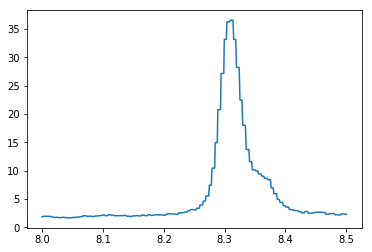

In [85]:
plt.plot(IAS_red['x'].values, IAS_red['y'].values)

In [102]:
def gauss(x, mu, sigma):
    return 35 * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.)))

def gauss2(x, mu, sigma):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.)))

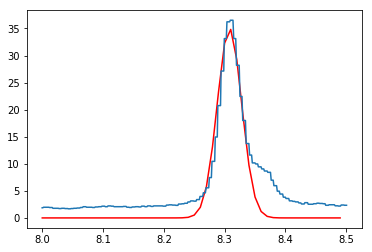

In [103]:
x = np.arange(8, 8.5, 0.01)
y = gauss(x, 8.308, 0.020)
plt.plot(x, y, c='r')
plt.plot(IAS_red['x'].values, IAS_red['y'].values)

In [106]:
from scipy.integrate import quad, trapz

In [108]:
quad(gauss, 8, 8.5, args=(8.308, 0.020))

(1.754639792241703, 9.955608006820965e-10)

In [112]:
trapz(y, x, dx=0.005)

1.7546397922417003

In [113]:
koeff  = 4.44